In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pickle

# Load clean dataset
df = pd.read_csv('/content/spotify_clean.csv')
print("Dataset shape:", df.shape)

# Load scaler
with open('/content/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
print("Scaler loaded!")

Dataset shape: (80140, 20)
Scaler loaded!


In [ ]:
# These 8 come from the CSV — scaler was fitted on exactly these
RL_FEATURES = ['danceability','energy','valence','tempo',
               'loudness','acousticness','instrumentalness','speechiness']

# transform (NOT fit_transform — scaler already fitted during cleaning)
df_scaled = df.copy()
df_scaled[RL_FEATURES] = scaler.transform(df[RL_FEATURES])

# song_matrix is (N, 8) — audio only, context added later at runtime
song_matrix = df_scaled[RL_FEATURES].values
print("song_matrix shape:", song_matrix.shape)  # e.g. (89740, 8)
print(df_scaled[RL_FEATURES].head(2))

song_matrix shape: (80140, 8)
   danceability    energy   valence     tempo  loudness  acousticness  \
0      0.669059  0.460989  0.718593  0.270336  0.779395      0.032329   
1      0.394881  0.165983  0.268342  0.221389  0.574223      0.927711   

   instrumentalness  speechiness  
0          0.000001     0.128221  
1          0.000006     0.057482  


In [ ]:
# The 4 context features are NOT from CSV.
# They are built fresh each episode from session state.
# Final vector fed to agent = 8 audio + 4 context = 12 dims

def build_context_vector(audio_8: np.ndarray, session: dict, song_idx: int) -> np.ndarray:
    """
    audio_8  : 1D array of 8 scaled audio features from song_matrix[i]
    session  : dict with runtime info (hour, activity, skips, recent_ids)
    song_idx : original index in song_matrix (to check recency)
    Returns  : 12-dim numpy array
    """
    time_norm = session['hour'] / 24.0                               # 0–1
    activity  = session['activity']                                   # 0.0 / 0.5 / 1.0
    skip_rate = session['skips'] / max(session['total_played'], 1)   # 0–1
    recency   = 1.0 if song_idx in session['recent_ids'] else 0.0   # 0 or 1

    context_4 = np.array([time_norm, activity, skip_rate, recency])

    return np.concatenate([audio_8, context_4])  # shape (12,)

In [ ]:
class SimulatedUser:
    def __init__(self, seed=None):
        rng = np.random.default_rng(seed)
        self.pref_energy       = rng.uniform(0.2, 0.9)
        self.pref_valence      = rng.uniform(0.2, 0.9)
        self.pref_danceability = rng.uniform(0.2, 0.9)
        self.pref_tempo        = rng.uniform(0.2, 0.9)
        self.pref_acousticness = rng.uniform(0.1, 0.8)
        self.rng               = rng

    def get_reward(self, song: dict, action: str = None) -> float:
        if action == 'favourite':  return  3.0
        if action == 'remove':     return -2.0
        if action == 'complete':   return  2.0
        if action == 'skip_half':  return  0.5
        if action == 'skip_early': return -1.0

        score = 1 - (
            abs(song['energy']       - self.pref_energy)       +
            abs(song['valence']      - self.pref_valence)       +
            abs(song['danceability'] - self.pref_danceability)  +
            abs(song['tempo']        - self.pref_tempo)         +
            abs(song['acousticness'] - self.pref_acousticness)
        ) / 5

        noise = self.rng.normal(0, 0.08)
        score = np.clip(score + noise, 0, 1)

        if score > 0.92 and self.rng.random() < 0.15:  return  3.0
        if score < 0.15 and self.rng.random() < 0.10:  return -2.0
        if score > 0.75:  return  2.0
        elif score > 0.5: return  0.5
        else:             return -1.0

In [ ]:
class LinUCBAgent:
    def __init__(self, n_features=12, alpha=0.3):
        self.alpha = alpha
        self.n     = n_features
        self.A     = np.identity(n_features)
        self.b     = np.zeros(n_features)

    def select(self, candidates: np.ndarray) -> int:
        A_inv  = np.linalg.inv(self.A)
        theta  = A_inv @ self.b
        scores = []
        for x in candidates:
            exploit = theta @ x
            explore = self.alpha * np.sqrt(x @ A_inv @ x)
            scores.append(exploit + explore)
        return int(np.argmax(scores))

    def update(self, x: np.ndarray, reward: float):
        self.A += np.outer(x, x)
        self.b += reward * x

In [ ]:
# Each user gets their own LinUCBAgent so preferences don't mix
user_agents  = {}  # user_id (str) → LinUCBAgent
user_history = {}  # user_id (str) → list of interaction dicts

def get_or_create_agent(user_id: str) -> LinUCBAgent:
    if user_id not in user_agents:
        user_agents[user_id]  = LinUCBAgent(n_features=12, alpha=0.3)
        user_history[user_id] = []
    return user_agents[user_id]

def log_interaction(user_id: str, song_idx: int, reward: float, action: str):
    user_history[user_id].append({
        'song_idx'  : song_idx,
        'reward'    : reward,
        'action'    : action,
        'timestamp' : pd.Timestamp.now()
    })

In [ ]:
def cold_start_songs(df: pd.DataFrame, n: int = 20) -> pd.DataFrame:
    """
    New users have no history so agent has nothing to go on.
    Pick top-popularity songs spread across 10 genres for diverse first impression.
    """
    top_genres = df['track_genre'].value_counts().head(10).index.tolist()
    per_genre  = max(1, n // len(top_genres))
    picks = []

    for genre in top_genres:
        genre_df = df[df['track_genre'] == genre].nlargest(20, 'popularity')
        picks.append(genre_df.head(per_genre))

    result = (pd.concat(picks)
                .drop_duplicates(subset='track_id')
                .head(n)
                .reset_index(drop=True))
    return result

# Test
cold_df = cold_start_songs(df, n=20)
print(cold_df[['track_name', 'artists', 'track_genre', 'popularity']])

                                           track_name  \
0                  Amante, Amiga e Namorada - Ao Vivo   
1                                  Esqueceu Foi Porra   
2                                             Breathe   
3                                    Hey Boy Hey Girl   
4                                           Yggdrasil   
5                                  One Night in Tokyo   
6                  Dancin (feat. Luvli) - Krono Remix   
7                                Dancin - Krono Remix   
8                 Lost in the Fire (feat. The Weeknd)   
9                             I Got Summer On My Mind   
10    Hakuna Matata - From "The Lion King"/Soundtrack   
11  You've Got a Friend in Me - From "Toy Story"/S...   
12                                         Doomswitch   
13                                      Freezing Moon   
14                                       Plastic Love   
15                                  Gimme Chocolate!!   
16                             

In [ ]:
N_EPISODES = 2000
POOL_SIZE  = 50

user = SimulatedUser(seed=42)

# Reset BOTH dicts before recreating
user_agents['sim_user']  = LinUCBAgent(n_features=12, alpha=0.3)
user_history['sim_user'] = []   # ← this line was missing
agent = get_or_create_agent('sim_user')

rewards_log = []
recent_ids  = []

for ep in range(N_EPISODES):

    session = {
        'hour'        : np.random.randint(0, 24),
        'activity'    : np.random.choice([0.0, 0.5, 1.0]),
        'skips'       : sum(1 for r in rewards_log[-20:] if r < 0),
        'total_played': min(ep + 1, 20),
        'recent_ids'  : set(recent_ids[-20:])
    }

    idxs       = np.random.choice(len(song_matrix), POOL_SIZE, replace=False)
    pool_audio = song_matrix[idxs]

    pool_12 = np.array([
        build_context_vector(pool_audio[i], session, idxs[i])
        for i in range(POOL_SIZE)
    ])

    chosen_idx  = agent.select(pool_12)
    chosen_song = df_scaled.iloc[idxs[chosen_idx]][RL_FEATURES].to_dict()

    reward = user.get_reward(chosen_song)

    agent.update(pool_12[chosen_idx], reward)
    rewards_log.append(reward)
    log_interaction('sim_user', int(idxs[chosen_idx]), reward, 'simulated')

    recent_ids.append(int(idxs[chosen_idx]))
    if len(recent_ids) > 20:
        recent_ids.pop(0)

    if ep % 100 == 0:
        avg = np.mean(rewards_log[-100:])
        print(f"Episode {ep:4d} | Avg Reward (last 100): {avg:.3f}")

Episode    0 | Avg Reward (last 100): 0.500
Episode  100 | Avg Reward (last 100): 1.725
Episode  200 | Avg Reward (last 100): 1.805
Episode  300 | Avg Reward (last 100): 1.905
Episode  400 | Avg Reward (last 100): 1.810
Episode  500 | Avg Reward (last 100): 1.815
Episode  600 | Avg Reward (last 100): 1.810
Episode  700 | Avg Reward (last 100): 1.840
Episode  800 | Avg Reward (last 100): 1.790
Episode  900 | Avg Reward (last 100): 1.835
Episode 1000 | Avg Reward (last 100): 1.845
Episode 1100 | Avg Reward (last 100): 1.840
Episode 1200 | Avg Reward (last 100): 1.865
Episode 1300 | Avg Reward (last 100): 1.765
Episode 1400 | Avg Reward (last 100): 1.910
Episode 1500 | Avg Reward (last 100): 1.800
Episode 1600 | Avg Reward (last 100): 1.850
Episode 1700 | Avg Reward (last 100): 1.880
Episode 1800 | Avg Reward (last 100): 1.910
Episode 1900 | Avg Reward (last 100): 1.920


In [ ]:
# ---- Random baseline ----
random_rewards = []
random_user    = SimulatedUser(seed=42)

for _ in range(N_EPISODES):
    idx  = np.random.randint(len(song_matrix))
    song = df_scaled.iloc[idx][RL_FEATURES].to_dict()
    random_rewards.append(random_user.get_reward(song))

# ---- Popularity baseline ----
pop_df      = df_scaled.nlargest(500, 'popularity')
pop_rewards = []
pop_user    = SimulatedUser(seed=42)

for i in range(N_EPISODES):
    song = pop_df.iloc[i % len(pop_df)][RL_FEATURES].to_dict()
    pop_rewards.append(pop_user.get_reward(song))

print("=" * 40)
print(f"  Random     avg reward: {np.mean(random_rewards):.3f}")
print(f"  Popularity avg reward: {np.mean(pop_rewards):.3f}")
print(f"  LinUCB     avg reward: {np.mean(rewards_log):.3f}")
print("=" * 40)

  Random     avg reward: 1.242
  Popularity avg reward: 1.569
  LinUCB     avg reward: 1.835


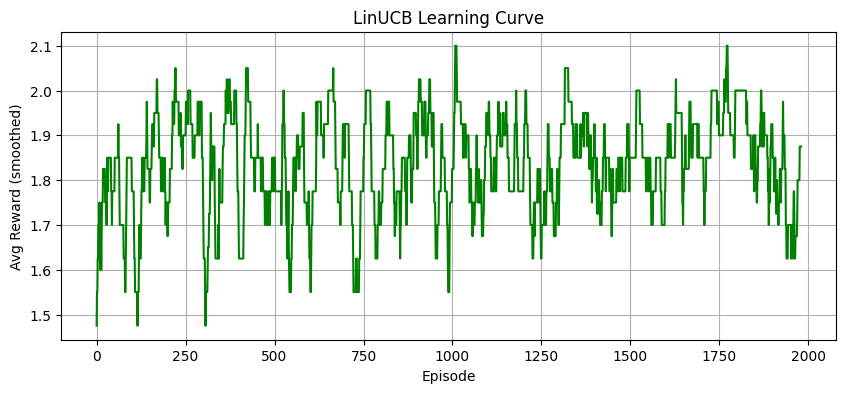

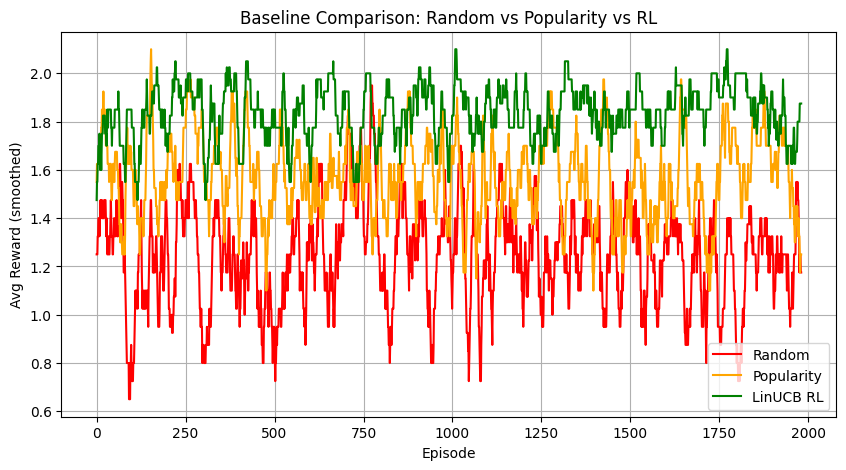

In [ ]:
import matplotlib.pyplot as plt

window = 20

def smooth(arr):
    return np.convolve(arr, np.ones(window)/window, mode='valid')

# Plot 1: LinUCB learning curve alone
plt.figure(figsize=(10, 4))
plt.plot(smooth(rewards_log), color='green')
plt.title('LinUCB Learning Curve')
plt.xlabel('Episode')
plt.ylabel('Avg Reward (smoothed)')
plt.grid(True)
plt.savefig('learning_curve.png')
plt.show()

# Plot 2: All 3 baselines together
plt.figure(figsize=(10, 5))
plt.plot(smooth(random_rewards), label='Random',     color='red')
plt.plot(smooth(pop_rewards),    label='Popularity', color='orange')
plt.plot(smooth(rewards_log),    label='LinUCB RL',  color='green')
plt.title('Baseline Comparison: Random vs Popularity vs RL')
plt.xlabel('Episode')
plt.ylabel('Avg Reward (smoothed)')
plt.legend()
plt.grid(True)
plt.savefig('baseline_comparison.png')
plt.show()

In [ ]:
def compute_diversity(indices: list, matrix: np.ndarray) -> float:
    vecs  = matrix[indices]
    dists = [np.linalg.norm(vecs[i] - vecs[j])
             for i in range(len(vecs))
             for j in range(i+1, len(vecs))]
    return float(np.mean(dists)) if dists else 0.0

def compute_serendipity(rec_indices: list, hist_indices: list, matrix: np.ndarray) -> float:
    if not hist_indices:
        return 1.0
    rec_vecs  = matrix[rec_indices]
    hist_vecs = matrix[hist_indices]
    dists     = [np.linalg.norm(r - h) for r in rec_vecs for h in hist_vecs]
    return float(np.mean(dists))

last_20   = recent_ids[-20:]
diversity = compute_diversity(last_20, song_matrix)
serendip  = compute_serendipity(last_20[:10], last_20[10:], song_matrix)
print(f"Diversity  : {diversity:.3f}")
print(f"Serendipity: {serendip:.3f}")

Diversity  : 0.560
Serendipity: 0.565


In [ ]:
def skip_analytics(rewards: list) -> dict:
    arr = np.array(rewards)
    return {
        'total_episodes'  : len(arr),
        'completion_rate' : float(np.mean(arr ==  2.0)),
        'half_skip_rate'  : float(np.mean(arr ==  0.5)),
        'early_skip_rate' : float(np.mean(arr == -1.0)),
        'favourite_rate'  : float(np.mean(arr ==  3.0)),
        'avg_reward'      : float(np.mean(arr)),
        'reward_trend'    : float(np.polyfit(range(len(arr)), arr, 1)[0])
    }

analytics = skip_analytics(rewards_log)
for k, v in analytics.items():
    print(f"  {k:<20}: {v:.4f}")

  total_episodes      : 2000.0000
  completion_rate     : 0.8390
  half_skip_rate      : 0.1305
  early_skip_rate     : 0.0000
  favourite_rate      : 0.0305
  avg_reward          : 1.8348
  reward_trend        : 0.0000


In [ ]:
# Agent
with open('linucb_agent.pkl', 'wb') as f:
    pickle.dump(agent, f)

# Reward logs
np.save('random_rewards.npy', np.array(random_rewards))
np.save('pop_rewards.npy',    np.array(pop_rewards))
np.save('rl_rewards.npy',     np.array(rewards_log))

# Feature matrix
np.save('feature_matrix.npy', song_matrix)

# Clean dataset (already saved in cleaning notebook but save again to be safe)
df.to_csv('spotify_clean.csv', index=False)

print("All saved!")

All saved!


# EXTRA EXPERIMENTS

In [ ]:
RL_FEATURES = ['danceability','energy','valence','tempo',
               'loudness','acousticness','instrumentalness','speechiness']

df_scaled = df.copy()
df_scaled[RL_FEATURES] = scaler.transform(df[RL_FEATURES])  # transform NOT fit_transform
print("df_scaled ready:", df_scaled.shape)
print(df_scaled[RL_FEATURES].head(2))

df_scaled ready: (80140, 20)
   danceability    energy   valence     tempo  loudness  acousticness  \
0      0.669059  0.460989  0.718593  0.270336  0.779395      0.032329   
1      0.394881  0.165983  0.268342  0.221389  0.574223      0.927711   

   instrumentalness  speechiness  
0          0.000001     0.128221  
1          0.000006     0.057482  


In [ ]:
import numpy as np

class SimulatedUser:
    def __init__(self, seed=None):
        rng = np.random.default_rng(seed)
        # Hidden preferences — agent must LEARN these
        self.pref_energy       = rng.uniform(0.2, 0.9)
        self.pref_valence      = rng.uniform(0.2, 0.9)
        self.pref_danceability = rng.uniform(0.2, 0.9)

    def get_reward(self, song: dict) -> float:
        score = 1 - (
            abs(song['energy']       - self.pref_energy) +
            abs(song['valence']      - self.pref_valence) +
            abs(song['danceability'] - self.pref_danceability)
        ) / 3

        if score > 0.75: return 2.0    # completed
        elif score > 0.5: return 0.5   # skipped after 50%
        else: return -1.0              # skipped early

In [ ]:
class LinUCBAgent:
    def __init__(self, n_features=8, alpha=1.0):
        self.alpha = alpha
        self.A = np.identity(n_features)
        self.b = np.zeros(n_features)

    def select(self, candidates: np.ndarray) -> int:
        theta = np.linalg.inv(self.A) @ self.b
        scores = []
        A_inv = np.linalg.inv(self.A)
        for x in candidates:
            exploit = theta @ x
            explore = self.alpha * np.sqrt(x @ A_inv @ x)
            scores.append(exploit + explore)
        return int(np.argmax(scores))

    def update(self, x: np.ndarray, reward: float):
        self.A += np.outer(x, x)
        self.b += reward * x

In [ ]:
RL_FEATURES = ['danceability','energy','valence','tempo',
               'loudness','acousticness','instrumentalness','speechiness']

song_matrix = df_scaled[RL_FEATURES].values  # shape (N, 8)
N_EPISODES  = 500
POOL_SIZE   = 50   # agent picks from 50 random songs each step

user  = SimulatedUser(seed=42)
agent = LinUCBAgent(n_features=8, alpha=1.2)

rewards_log = []

for ep in range(N_EPISODES):
    # Random candidate pool
    idxs = np.random.choice(len(song_matrix), POOL_SIZE, replace=False)
    pool = song_matrix[idxs]

    chosen_idx = agent.select(pool)
    chosen_song = df_scaled.iloc[idxs[chosen_idx]][RL_FEATURES].to_dict()

    reward = user.get_reward(chosen_song)
    agent.update(pool[chosen_idx], reward)
    rewards_log.append(reward)

    if ep % 50 == 0:
        avg = np.mean(rewards_log[-50:])
        print(f"Episode {ep:4d} | Avg Reward: {avg:.3f}")

Episode    0 | Avg Reward: 2.000
Episode   50 | Avg Reward: 1.670
Episode  100 | Avg Reward: 1.850
Episode  150 | Avg Reward: 1.850
Episode  200 | Avg Reward: 1.940
Episode  250 | Avg Reward: 2.000
Episode  300 | Avg Reward: 1.880
Episode  350 | Avg Reward: 2.000
Episode  400 | Avg Reward: 1.940
Episode  450 | Avg Reward: 1.970


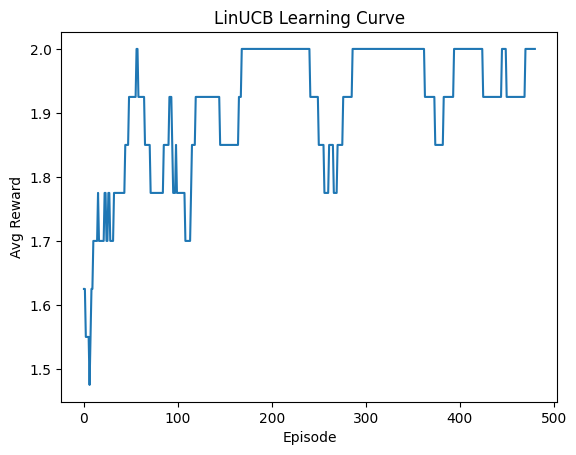

In [ ]:
import matplotlib.pyplot as plt

window = 20
smoothed = np.convolve(rewards_log, np.ones(window)/window, mode='valid')
plt.plot(smoothed)
plt.title("LinUCB Learning Curve")
plt.xlabel("Episode"); plt.ylabel("Avg Reward")
plt.savefig("learning_curve.png")
plt.show()

In [ ]:
import pickle
with open('linucb_agent.pkl', 'wb') as f:
    pickle.dump(agent, f)
print("Agent saved!")

Agent saved!


# BASELINE

In [ ]:
# RANDOM BASELINE — picks songs randomly, no learning
random_rewards = []
random_user = SimulatedUser(seed=42)  # same user as RL

for _ in range(500):
    idx = np.random.randint(len(song_matrix))
    song = df_scaled.iloc[idx][RL_FEATURES].to_dict()
    reward = random_user.get_reward(song)
    random_rewards.append(reward)

print(f"Random Avg Reward: {np.mean(random_rewards):.3f}")

Random Avg Reward: 1.361


In [ ]:
# POPULARITY BASELINE — always picks most popular songs
pop_df = df_scaled.nlargest(500, 'popularity')
pop_rewards = []
pop_user = SimulatedUser(seed=42)  # same user

for i in range(500):
    song = pop_df.iloc[i % len(pop_df)][RL_FEATURES].to_dict()
    reward = pop_user.get_reward(song)
    pop_rewards.append(reward)

print(f"Popularity Avg Reward: {np.mean(pop_rewards):.3f}")

Popularity Avg Reward: 1.769


In [ ]:
print("=" * 35)
print(f"  Random     avg reward: {np.mean(random_rewards):.3f}")
print(f"  Popularity avg reward: {np.mean(pop_rewards):.3f}")
print(f"  LinUCB     avg reward: {np.mean(rewards_log):.3f}")
print("=" * 35)

  Random     avg reward: 1.361
  Popularity avg reward: 1.769
  LinUCB     avg reward: 1.907


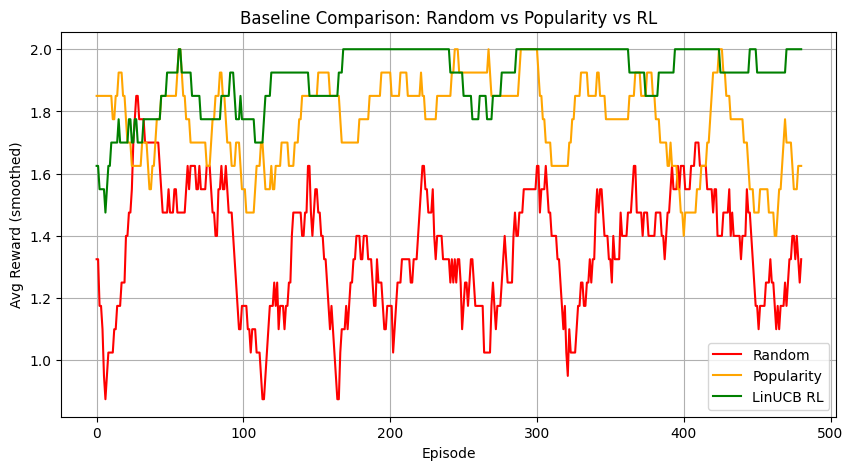

In [ ]:
import matplotlib.pyplot as plt

window = 20

def smooth(arr):
    return np.convolve(arr, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(smooth(random_rewards), label='Random',     color='red')
plt.plot(smooth(pop_rewards),    label='Popularity', color='orange')
plt.plot(smooth(rewards_log),    label='LinUCB RL',  color='green')

plt.title('Baseline Comparison: Random vs Popularity vs RL')
plt.xlabel('Episode')
plt.ylabel('Avg Reward (smoothed)')
plt.legend()
plt.grid(True)
plt.savefig('baseline_comparison.png')
plt.show()

In [ ]:
import pickle
import numpy as np

# Save agent
with open('linucb_agent.pkl', 'wb') as f:
    pickle.dump(agent, f)

# Save results for report
np.save('random_rewards.npy', random_rewards)
np.save('pop_rewards.npy', pop_rewards)
np.save('rl_rewards.npy', rewards_log)

print("All saved!")

All saved!
